# UCI HAR Dataset 기반 CNN 분류

### UCI HAR Dataset
   - 스마트폰 센서 데이터를 이용해 사람의 행동을 분류하기 위해 만들어진 대표적인 시계열 분류 데이터셋

### Dataset에 활용된 센서
  - 가속도 센서 (accelerometer)
    - 움직임에 따른 가속도, 중력 방향 측정
  - 자이로 센서 (gyroscope)
    - 회전 속도 측정
### 센서를 통해 수집된 데이터
- WALKING : 걷기
- WALKING_UPSTAIRS : 계단 오르기
- WALKING_DOWNSTAIRS : 계단 내려가기
- SITTING : 앉기
- STANDING : 서있기
- LAYING : 눕기

### 데이터 설명

- body_acc_x, y, z : 몸의 순수 가속도
- body_gyro_x, y, z : 각속도
- total_acc_x, y, z : 전체 가속도

하나의 샘플은 **(128, 9)** 형태로 구성

- 128: 시간 길이  
- 9: 센서 특성 수

In [ ]:
# 라이브러리 import
import numpy as np #수치 계산용
import tensorflow as tf #딥러닝 프레임워크
import matplotlib.pyplot as plt # 학습 곡선 시각화(그래프)
import seaborn as sns #시각화

from tensorflow.keras.models import Model #Functional API 방식으로 모델 구성 클래스
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, Add, GaussianNoise
) #모델의 부품
from tensorflow.keras.optimizers import Adam #optimizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau #학습 도중 자동 제어 장치

from sklearn.metrics import classification_report, confusion_matrix #학습 후 성능 분석용

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                # 1. 공백 정리
                # 2. 양끝 공백 제거
                # 3. 공백 기준으로 split -> 문자열 숫자 리스트로 변환
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # CNN 입력 형태로 변환
    # (channels, samples, time) -> (samples, time, channels)
    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [ ]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:

            # 문자열 형태의 숫자를 읽어서 공백 제거 후 정수로 변환
            y.append(int(row.strip()))

    # 리스트 -> numpy 배열로 변환
    y = np.array(y, dtype=np.int32)

    # 원래 라벨이 1~6이라서 딥러닝에서 사용하 0~5로 변경
    return y - 1

In [ ]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [ ]:
# 데이터 표준화
# 채널마다 값의 범위가 다를 수 있어서
# 평균 0, 표준편차 1 근처로 맞춰주면 학습이 더 안정적임

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("표준화 완료")

표준화 완료


In [ ]:
# One-hot 인코딩
# softmax 출력과 label smoothing을 쓰기 위해 one-hot으로 변환
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


## Residual Block
기존 정보를 유지하면서 필요한 변화만 학습하도록 만들어 깊은 모델에서도 학습이 잘 되게 해주는 구조

### 사용 목적
깊은 CNN 구조에서도 학습이 안정적으로 이루어지도록 하기 위해 사용

### 사용 이유
성능 향상을 위해 모델을 깊게 설계하게 되면 gradient vanishing이나 성능 저하 문제가 발생할 수 있기 때문에 이를 완화하고 기존 정보를 유지하면서 추가적인 특징을 학습하기 위해 사용

In [ ]:
# Residual Block 정의
def residual_block(x, filters, kernel_size=3, pool=True):
    shortcut = x # 입력을 그대로 보관

    # 입력 채널 수와 출력 채널 수가 다르면 1x1 conv로 맞춤
    if x.shape[-1] != filters:
        # 1x1 Conv로 채널 수만 변환
        shortcut = Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # 첫 번째 Conv: 기본적인 시간 패턴 추출
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x) # 분포 정규화
    x = ReLU()(x) # 비선형성 추가

    # 두 번째 Conv: 더 복잡한 특징 학습
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    # Residual 연결: 기존 입력 + 새로 학습한 특징
    x = Add()([x, shortcut])
    x = ReLU()(x) # 최종 활성화

    # 필요 시 시간 길이를 절반으로 줄임
    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

##Batch Normalization
BatchNorm은 activation distribution(레이어를 통과한 출력값들의 분포)을 적절히 관리해서 학습을 빠르고 안정적으로 만들기 위한 층

###핵심 사용 목적
1. 중간 feature 분포를 정규화
2. 학습 안정화
3. 더 큰 learning rate 사용 가능
4. 약한 regularization 효과

In [ ]:
# CNN 모델 정의
def build_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape) # 모델 입력층 생성

    # 약한 노이즈 추가: 특정 데이터에 대한 과적합 방지
    x = GaussianNoise(0.01)(inputs)

    # 서로 다른 크기의 커널로 Conv 수행
    b1 = Conv1D(64, kernel_size=3, padding='same', use_bias=False)(x)
    b2 = Conv1D(64, kernel_size=5, padding='same', use_bias=False)(x)
    b3 = Conv1D(64, kernel_size=7, padding='same', use_bias=False)(x)

    # 여러 스케일에서 추출한 특징을 채널 방향으로 합침
    x = Concatenate()([b1, b2, b3])
    x = BatchNormalization()(x) # 값의 분포를 안정화
    x = ReLU()(x) # 비선형성 추가

    # Residual CNN blocks
    x = residual_block(x, filters=128, kernel_size=3, pool=True)
    x = residual_block(x, filters=256, kernel_size=3, pool=True)
    x = residual_block(x, filters=256, kernel_size=5, pool=False)
    x = residual_block(x, filters=512, kernel_size=3, pool=False)

    # 평균 + 최대 pooling 같이 사용
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    # 두 정보를 합쳐 최종 특징 벡터 생성
    x = Concatenate()([avg_pool, max_pool])

    # 완전연결층: 추출된 특징을 바탕으로 분류에 적합한 표현으로 변환
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)

    # 최종 출력층: 클래스별 확률 출력
    outputs = Dense(num_classes, activation='softmax')(x)

    # 입력과 출력을 연결해 모델 생성
    model = Model(inputs, outputs)
    return model

In [ ]:
# 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])   # (128, 9)
num_classes = 6

model = build_cnn_model(input_shape, num_classes)

# 모델 학습 설정
model.compile(
    # optimizer 설정
    optimizer=Adam(learning_rate=3e-4),
    # 다중 분류 손실 함수 + label smoothing 적용(모델이 100% 확신 못하도록)
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    # 정확도
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_4    │ (None, 128, 9)    │          0 │ input_layer_4[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 128, 64)   │      1,728 │ gaussian_noise_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 128, 64)   │      2,880 │ gaussian_noise_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 128, 64)   │      4,032 │ gaussian_noise_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128, 192)  │          0 │ conv1d_47[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_48[0][0],  │
│                     │                   │            │ conv1d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 192)  │        768 │ concatenate_8[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 128, 192)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 128, 128)  │     73,728 │ re_lu_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_51[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_52 (Conv1D)  │ (None, 128, 128)  │     49,152 │ re_lu_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 128, 128)  │     24,576 │ re_lu_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_52[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_50[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 128, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 128, 128)  │          0 │ add_13[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 64, 128)   │          0 │ re_lu_32[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 64, 256)   │     98,304 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256)   │      1,024 │ conv1d_54[0][0] 

 Total params: 2,759,494 (10.53 MB)

 Trainable params: 2,752,710 (10.50 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [ ]:
# Callback 설정(학습 중 자동으로 개입)
callbacks = [

    # 가장 성능이 좋은 모델을 파일로 저장
    ModelCheckpoint(
        "UCI_HAR_CNN_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # 학습이 정체되면 learning rate 감소
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),

    # 조기 종료 : 더 이상 성능이 좋아지지 않으면 학습 종료
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=35,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=200, # 전체 데이터 반복 횟수
    batch_size=64, # 한번에 처리할 데이터 수
    validation_split=0.2,# train 데이터 중 20%를 테스트 용으로 사용
    callbacks=callbacks,# 학습 자동 제어
    shuffle=True, # 매 epoch마다 데이터 순서 섞기
    verbose=1 # 학습 진행 상황 출력
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7659 - loss: 0.9148
Epoch 1: val_accuracy improved from None to 0.92454, saving model to UCI_HAR_CNN_best.keras

Epoch 1: finished saving model to UCI_HAR_CNN_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - accuracy: 0.8788 - loss: 0.4947 - val_accuracy: 0.9245 - val_loss: 0.4646 - learning_rate: 3.0000e-04
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9529 - loss: 0.2534
Epoch 2: val_accuracy did not improve from 0.92454
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9526 - loss: 0.2494 - val_accuracy: 0.9225 - val_loss: 0.3428 - learning_rate: 3.0000e-04
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9556 - loss: 0.2438
Epoch 3: val_accuracy did not improve from 0.92454
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9524 - loss: 0.2422 - val_accuracy: 0.9211 - val_loss: 0.3807 - learning_rate: 3.0000e-04
Epoch 4/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - ac

In [ ]:
model = tf.keras.models.load_model("UCI_HAR_CNN_best.keras")

In [ ]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.32%
Training loss: 0.1451
Test accuracy: 96.13%
Test loss: 0.2354


In [ ]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9839    0.9919       496
           1     0.9955    0.9490    0.9717       471
           2     0.9313    1.0000    0.9644       420
           3     0.9574    0.8697    0.9114       491
           4     0.8970    0.9662    0.9303       532
           5     0.9944    1.0000    0.9972       537

    accuracy                         0.9613      2947
   macro avg     0.9626    0.9615    0.9612      2947
weighted avg     0.9628    0.9613    0.9612      2947



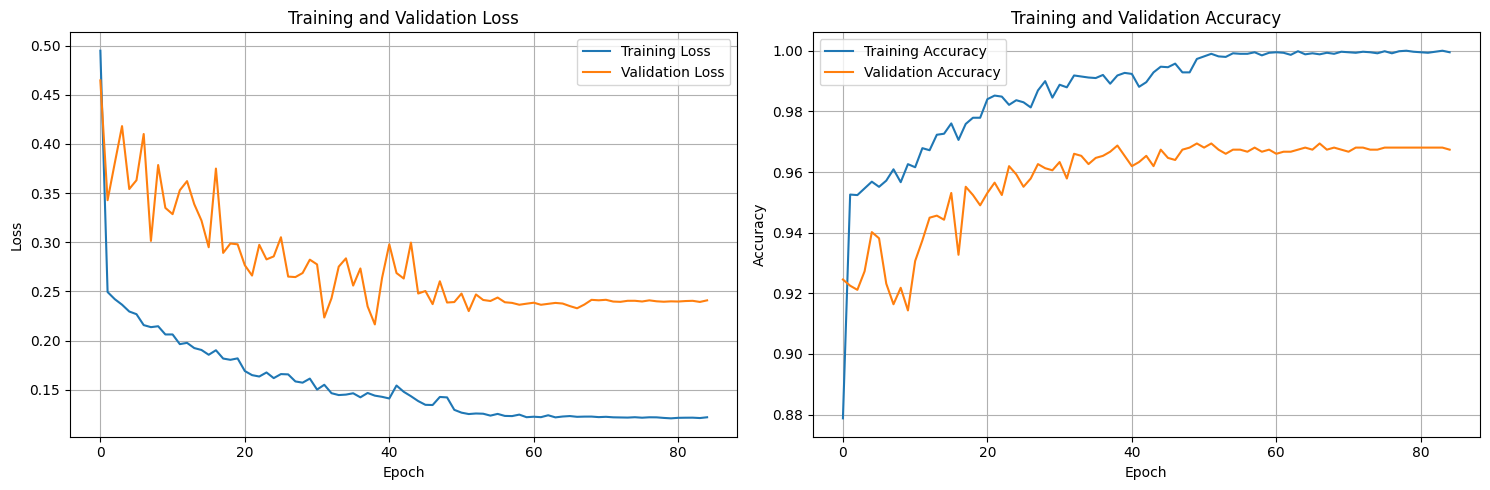

In [ ]:
# 학습 곡선 시각화
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

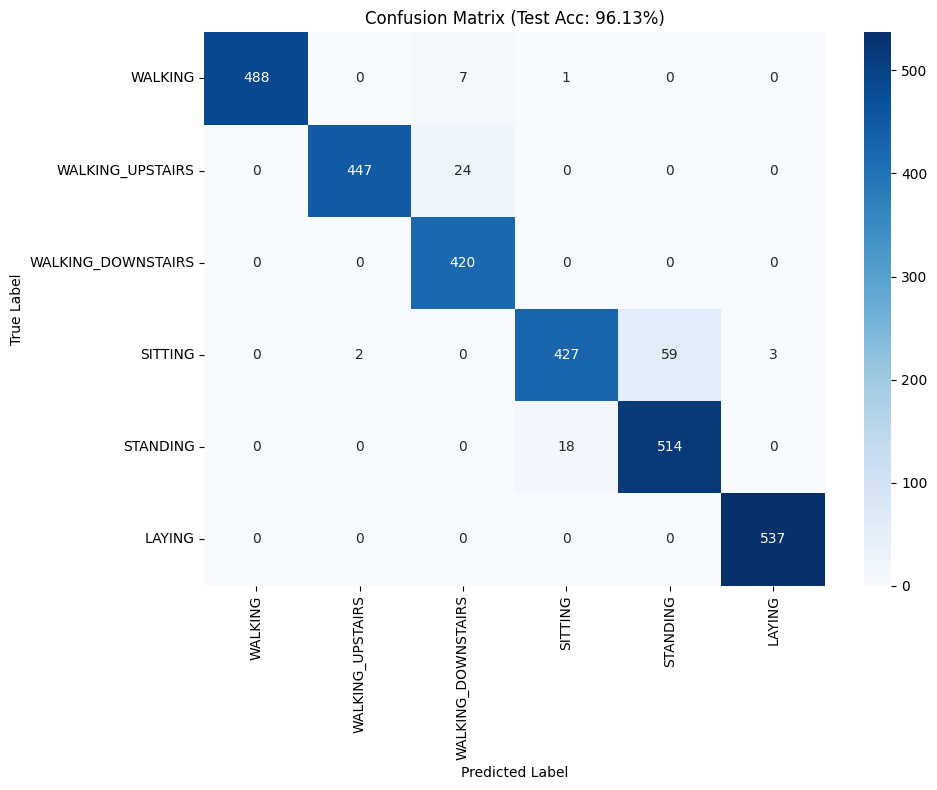

In [ ]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()